In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
df = pd.read_csv(r"C:\Users\amare\Downloads\data_center_hybrid.csv")
df.head()

,Year,Facility_ID,Facility_Name,Owner_Company,City,Country,Facility_Type,Estimated_Capacity_MW,PUE,Cooling_System_Type,WUE_L_per_kWh,Daily_Electricity_Usage_MWh,Daily_Water_Usage_Gallons,Surrounding_Water_Stress_Tier
0,2019,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.24,1.975,Evaporative,1.481,183.62,36362.94,Low
1,2020,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.36,1.967,Evaporative,1.459,254.34,49833.60,Low
2,2021,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.47,1.928,Evaporative,1.450,266.85,53026.35,Low
3,2022,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.59,1.897,Evaporative,1.413,199.14,39198.30,Low
4,2023,DC-D2763E00,NAP de las Americas Madrid,Terremark,Madrid,Spain,Enterprise/Standard,6.70,1.869,Evaporative,1.389,225.94,44366.48,Low


In [8]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126770 entries, 0 to 126769
Data columns (total 14 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Year                           126770 non-null  int64  
 1   Facility_ID                    126770 non-null  object 
 2   Facility_Name                  126770 non-null  object 
 3   Owner_Company                  126770 non-null  object 
 4   City                           126770 non-null  object 
 5   Country                        126770 non-null  object 
 6   Facility_Type                  126770 non-null  object 
 7   Estimated_Capacity_MW          126770 non-null  float64
 8   PUE                            126770 non-null  float64
 9   Cooling_System_Type            126770 non-null  object 
 10  WUE_L_per_kWh                  126770 non-null  float64
 11  Daily_Electricity_Usage_MWh    126770 non-null  float64
 12  Daily_Water_Usage_Gallons     

,Year,Estimated_Capacity_MW,PUE,WUE_L_per_kWh,Daily_Electricity_Usage_MWh,Daily_Water_Usage_Gallons
count,126770.000000,126770.000000,126770.000000,126770.000000,126770.000000,1.267700e+05
mean,2022.000000,23.075117,1.637746,0.820596,605.222368,1.312182e+05
std,2.000008,45.847195,0.190833,0.925481,1040.061940,3.979629e+05
min,2019.000000,1.000000,1.057000,0.001000,22.190000,2.240100e+02
25%,2020.000000,5.450000,1.518000,0.139000,167.432500,4.840538e+03
50%,2022.000000,9.870000,1.643000,0.232000,302.750000,1.218130e+04
75%,2024.000000,14.180000,1.787000,1.654000,451.370000,7.573068e+04
max,2025.000000,562.890000,2.000000,3.000000,14812.660000,7.585092e+06


<!-- Distribution Of Data Centers on PUE (Power Usage Efficiency) Values -->

# Distribution of Data Center on PUE Values Globally

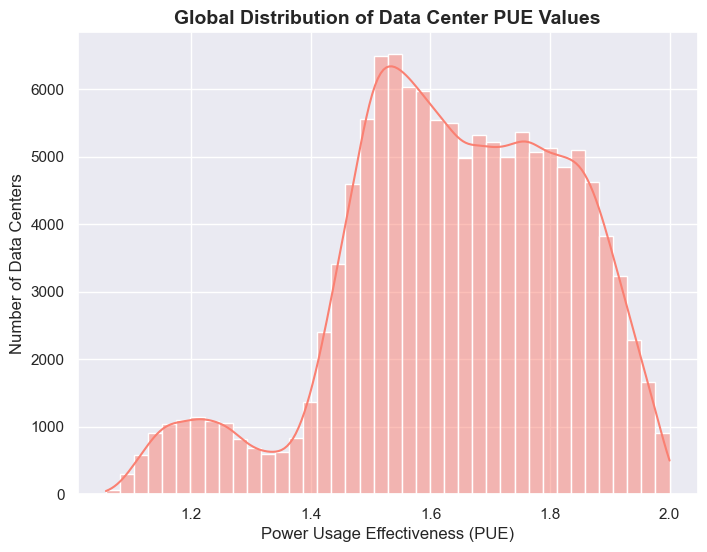

In [21]:
sns.set_theme(style="darkgrid")
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='PUE', bins=40, kde=True, color='salmon')
plt.title('Global Distribution of Data Center PUE Values', fontsize=14, fontweight='bold')
plt.xlabel('Power Usage Effectiveness (PUE)', fontsize=12)
plt.ylabel('Number of Data Centers', fontsize=12)

plt.show()

Efficient Peak (Around PUE 1.2) = modern, highly optimized data centers (very likely to be hyperscale facilities)that use advanced cooling techniques to keep overhead minimal.

Standard Peak (Between 1.5 - 1.6) = majority of standard enterprise data centers globally, where traditional cooling infrastructure still consumes a significant amount of power.

Minimum (1.057) = Highly efficient,almost zero energy is wasted on cooling or power loss.
Median (1.643) = more than half of the data centers in this dataset still operate with a PUE above 1.6.
Maximum (2.0) = uses as much energy on overhead as it does on actual computing.

# Distribution of Data Center on WUE Values Globally

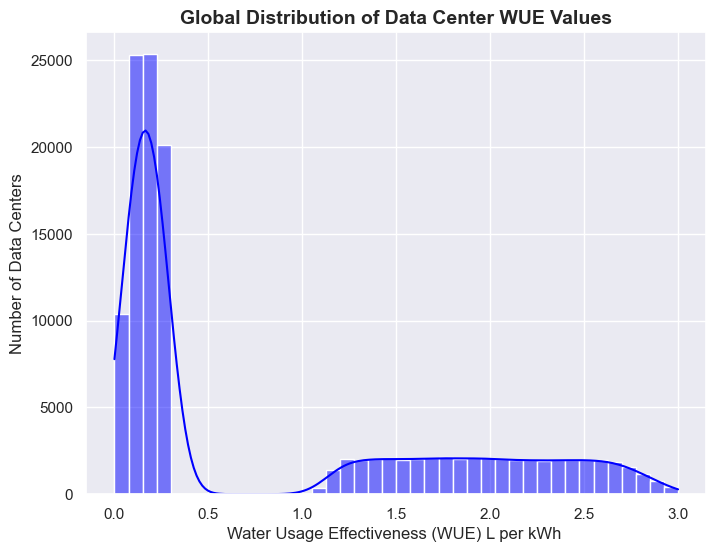

In [26]:
sns.set_theme(style="darkgrid")
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='WUE_L_per_kWh', bins=40, kde=True, color='blue')
plt.title('Global Distribution of Data Center WUE Values', fontsize=14, fontweight='bold')
plt.xlabel('Water Usage Effectiveness (WUE) L per kWh ', fontsize=12)
plt.ylabel('Number of Data Centers', fontsize=12)

plt.show()

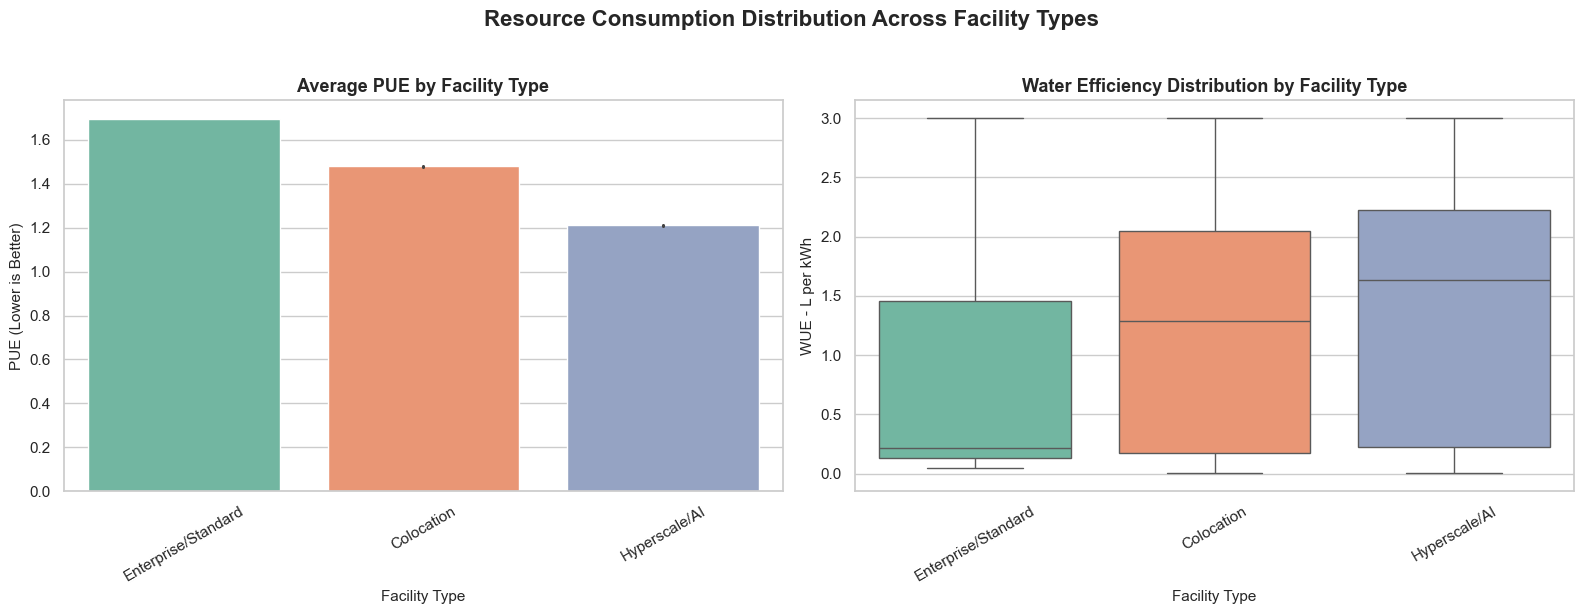

In [31]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=df, 
    x='Facility_Type', 
    y='PUE', 
    ax=axes[0], 
    palette='Set2',
    hue='Facility_Type', 
    legend=False
)
axes[0].set_title('Average PUE by Facility Type', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Facility Type', fontsize=11)
axes[0].set_ylabel('PUE (Lower is Better)', fontsize=11)
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(
    data=df, 
    x='Facility_Type', 
    y='WUE_L_per_kWh', 
    ax=axes[1], 
    palette='Set2',
    hue='Facility_Type',
    legend=False
)
axes[1].set_title('Water Efficiency Distribution by Facility Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Facility Type', fontsize=11)
axes[1].set_ylabel('WUE - L per kWh', fontsize=11)
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Resource Consumption Distribution Across Facility Types', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

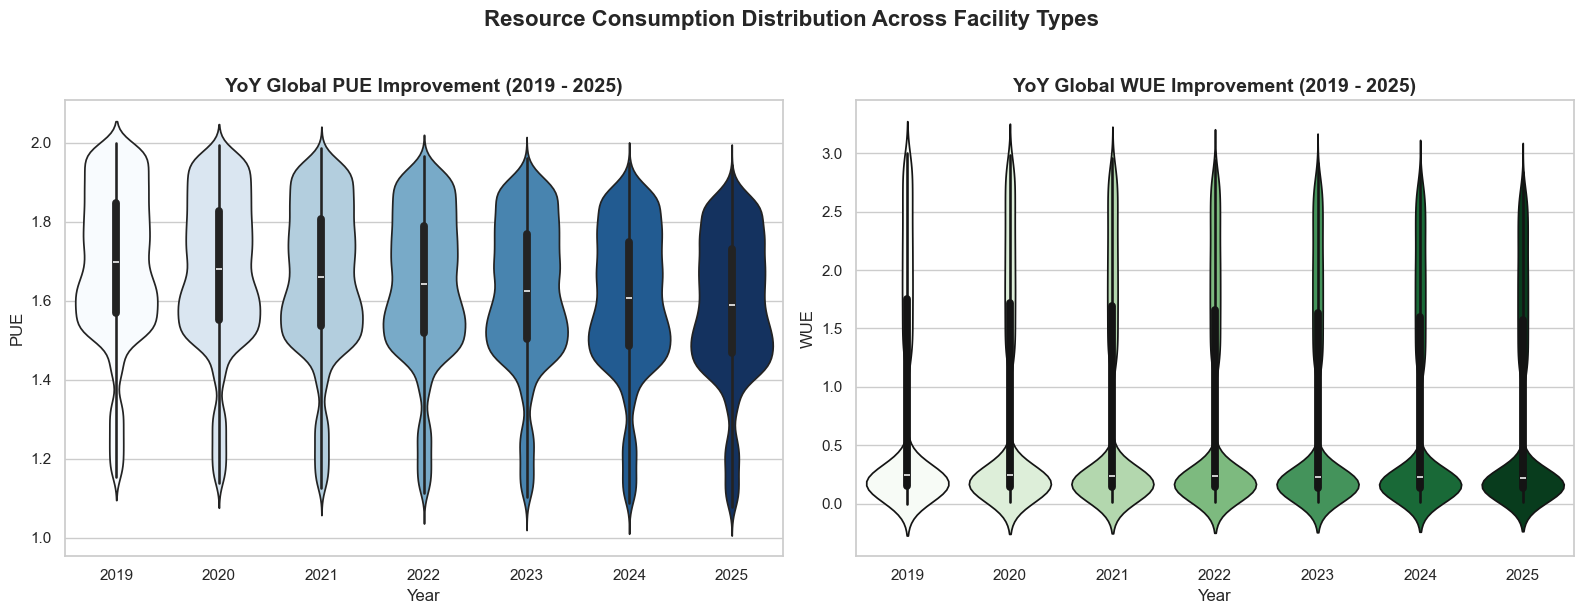

In [40]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.violinplot(data=df, x='Year', y='PUE', palette='Blues', hue='Year', legend=False,ax=axes[0])
axes[0].set_title('YoY Global PUE Improvement (2019 - 2025)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Year', fontsize=12)
axes[0].set_ylabel('PUE', fontsize=12)

sns.violinplot(data=df, x='Year', y='WUE_L_per_kWh', palette='Greens', hue='Year', legend=False,ax=axes[1])
axes[1].set_title('YoY Global WUE Improvement (2019 - 2025)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Year', fontsize=12)
axes[1].set_ylabel('WUE', fontsize=12)

plt.suptitle('Resource Consumption Distribution Across Facility Types', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

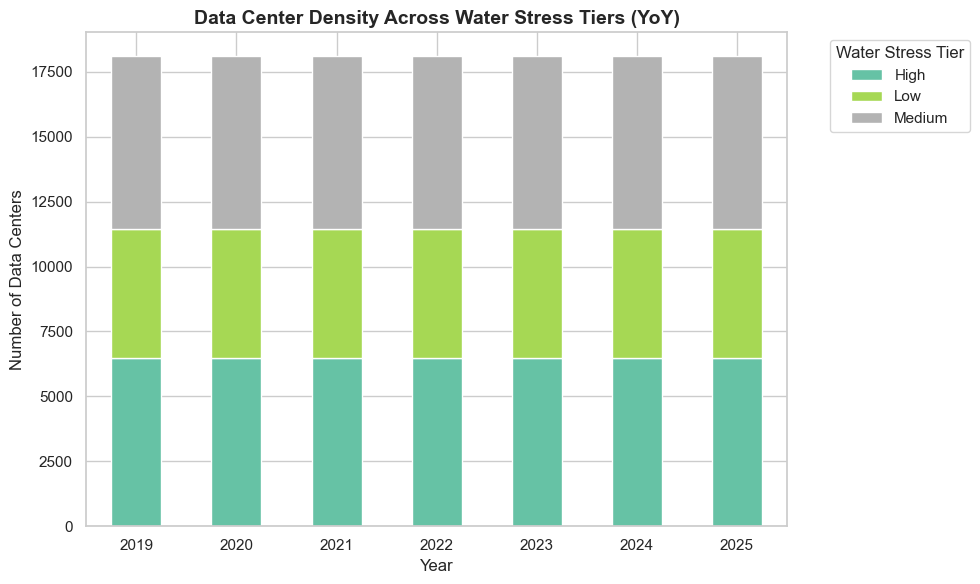

In [48]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Cross-tabulate and plot the counts
pd.crosstab(df['Year'], df['Surrounding_Water_Stress_Tier']).plot(
    kind='bar', 
    stacked=True, 
    colormap=('Set2'), # Heat-style color palette for stress levels
    ax=plt.gca()
)

plt.title('Data Center Density Across Water Stress Tiers (YoY)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Data Centers', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Water Stress Tier', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

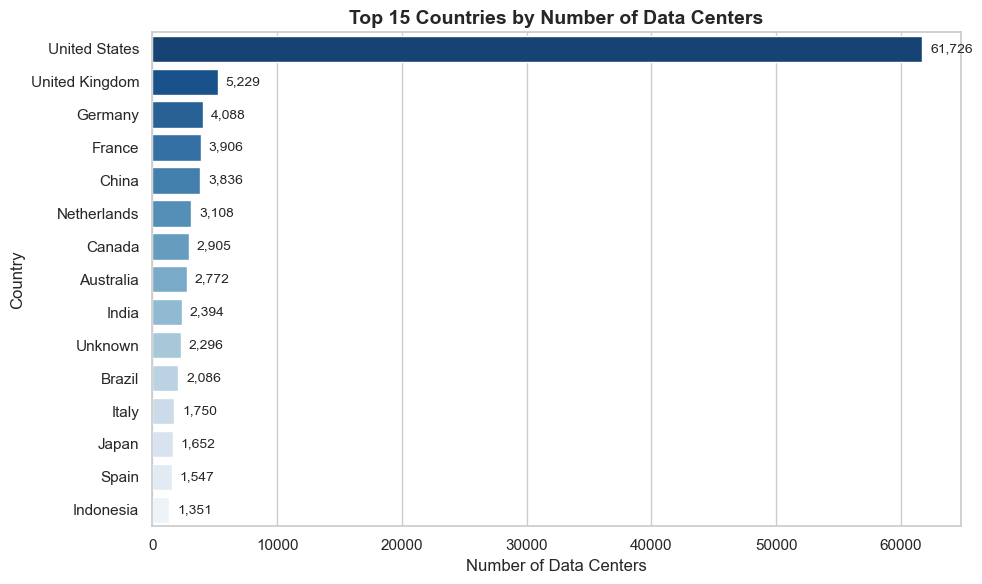

In [55]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

top_countries = df['Country'].value_counts().nlargest(15)

sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    palette='Blues_r',       
    hue=top_countries.index, 
    legend=False
)

plt.title('Top 15 Countries by Number of Data Centers', fontsize=14, fontweight='bold')
plt.xlabel('Number of Data Centers', fontsize=12)
plt.ylabel('Country', fontsize=12)

for index, value in enumerate(top_countries.values):
    plt.text(value + (max(top_countries.values)*0.01), index, f'{value:,}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

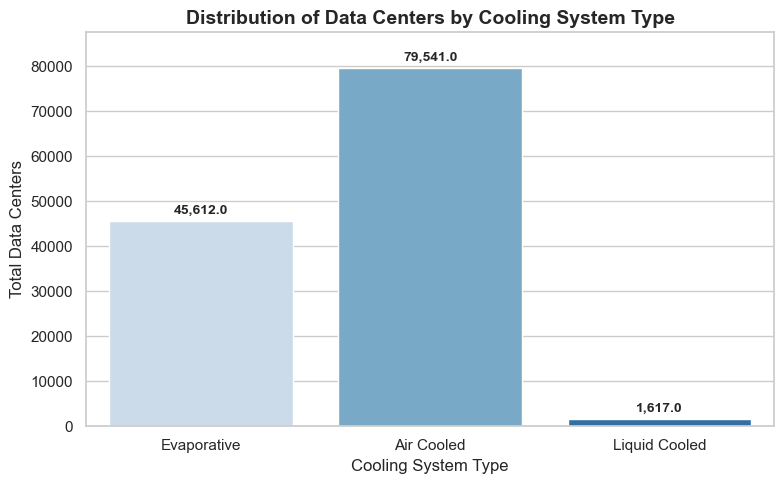

In [70]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df, 
    x='Cooling_System_Type', 
    palette='Blues', 
    hue='Cooling_System_Type', 
    legend=False
)
for container in ax.containers:
    ax.bar_label(container, fmt='{:,}', fontsize=10, fontweight='bold', padding=3)

plt.title('Distribution of Data Centers by Cooling System Type', fontsize=14, fontweight='bold')
plt.xlabel('Cooling System Type', fontsize=12)
plt.ylabel('Total Data Centers', fontsize=12)

plt.ylim(0, df['Cooling_System_Type'].value_counts().max() * 1.1)

plt.tight_layout()
plt.show()

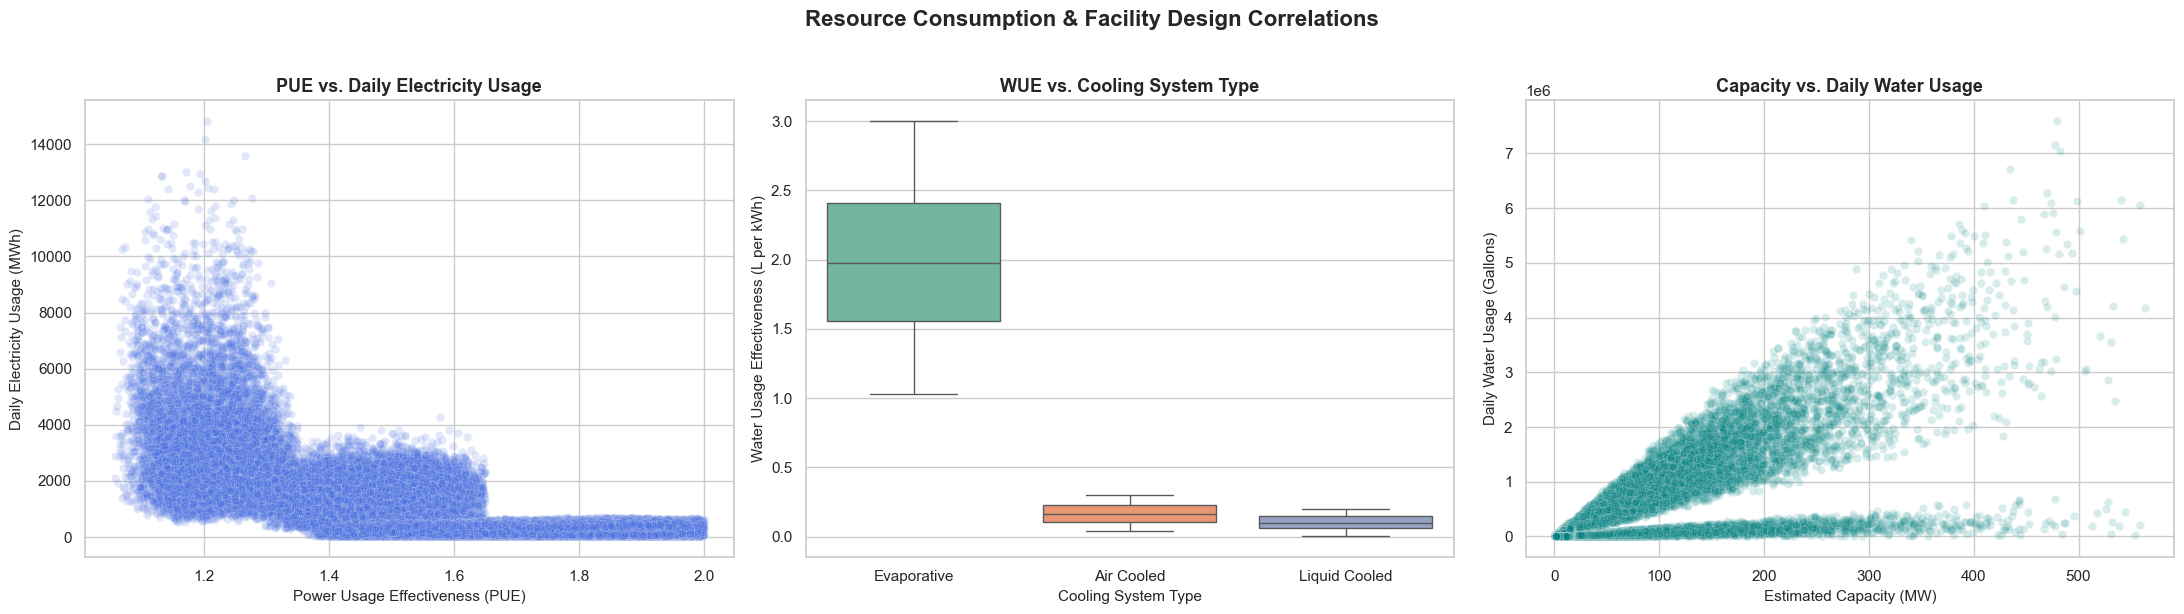

In [73]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.scatterplot(
    data=df, 
    x='PUE', 
    y='Daily_Electricity_Usage_MWh', 
    ax=axes[0], 
    alpha=0.15, 
    color='royalblue'
)
axes[0].set_title('PUE vs. Daily Electricity Usage', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Power Usage Effectiveness (PUE)', fontsize=11)
axes[0].set_ylabel('Daily Electricity Usage (MWh)', fontsize=11)

sns.boxplot(
    data=df, 
    x='Cooling_System_Type', 
    y='WUE_L_per_kWh', 
    ax=axes[1], 
    palette='Set2',
    hue='Cooling_System_Type', # Fixes modern Seaborn palette warnings
    legend=False
)
axes[1].set_title('WUE vs. Cooling System Type', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Cooling System Type', fontsize=11)
axes[1].set_ylabel('Water Usage Effectiveness (L per kWh)', fontsize=11)

sns.scatterplot(
    data=df, 
    x='Estimated_Capacity_MW', 
    y='Daily_Water_Usage_Gallons', 
    ax=axes[2], 
    alpha=0.15, 
    color='teal'
)
axes[2].set_title('Capacity vs. Daily Water Usage', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Estimated Capacity (MW)', fontsize=11)
axes[2].set_ylabel('Daily Water Usage (Gallons)', fontsize=11)

plt.suptitle('Resource Consumption & Facility Design Correlations', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

--- Average Metrics by Facility Type ---


,PUE,WUE_L_per_kWh,Estimated_Capacity_MW,Daily_Electricity_Usage_MWh,Daily_Water_Usage_Gallons
Facility_Type,,,,,
Colocation,1.479179,1.161890,51.945657,1425.906661,2.983745e+05
Enterprise/Standard,1.693435,0.726678,8.355626,262.811031,3.003673e+04
Hyperscale/AI,1.210476,1.439187,154.016644,3445.401239,1.074522e+06


<Figure size 1800x2000 with 0 Axes>

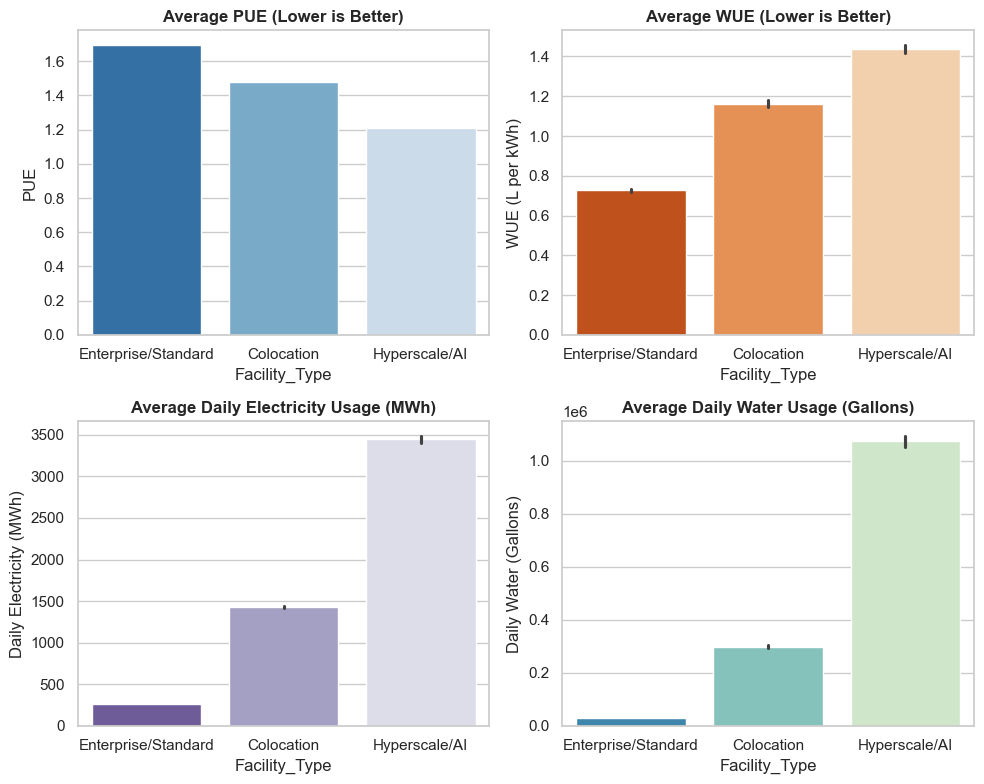

In [86]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18,20))
print("--- Average Metrics by Facility Type ---")
metrics_df = df.groupby('Facility_Type')[['PUE', 'WUE_L_per_kWh', 'Estimated_Capacity_MW', 
                                         'Daily_Electricity_Usage_MWh', 'Daily_Water_Usage_Gallons']].mean()
display(metrics_df)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

sns.barplot(data=df, x='Facility_Type', y='PUE', ax=axes[0, 0], palette='Blues_r', hue='Facility_Type', legend=False)
axes[0, 0].set_title('Average PUE (Lower is Better)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('PUE')

sns.barplot(data=df, x='Facility_Type', y='WUE_L_per_kWh', ax=axes[0, 1], palette='Oranges_r', hue='Facility_Type', legend=False)
axes[0, 1].set_title('Average WUE (Lower is Better)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('WUE (L per kWh)')

sns.barplot(data=df, x='Facility_Type', y='Daily_Electricity_Usage_MWh', ax=axes[1, 0], palette='Purples_r', hue='Facility_Type', legend=False)
axes[1, 0].set_title('Average Daily Electricity Usage (MWh)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Daily Electricity (MWh)')

sns.barplot(data=df, x='Facility_Type', y='Daily_Water_Usage_Gallons', ax=axes[1, 1], palette='GnBu_r', hue='Facility_Type', legend=False)
axes[1, 1].set_title('Average Daily Water Usage (Gallons)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Daily Water (Gallons)')

plt.tight_layout()
plt.show()

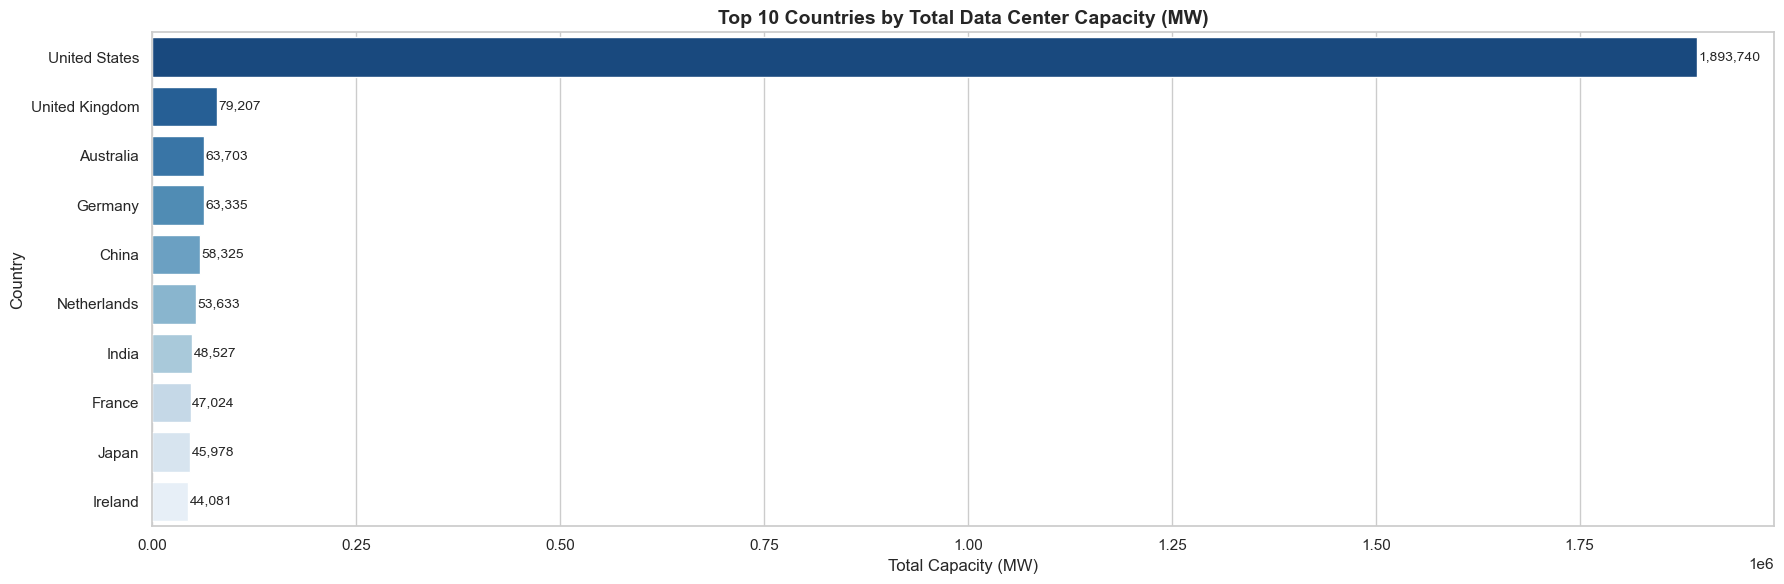

In [98]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 6))

top_countries = df.groupby('Country')['Estimated_Capacity_MW'].sum().nlargest(10)

sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    palette='Blues_r',       
    hue=top_countries.index, 
    legend=False
)

plt.title('Top 10 Countries by Total Data Center Capacity (MW)', fontsize=14, fontweight='bold')
plt.xlabel('Total Capacity (MW)', fontsize=12)
plt.ylabel('Country', fontsize=12)

# Fixed formatting to int here to remove the decimal points
for index, value in enumerate(top_countries.values):
    plt.text(value + (max(top_countries.values)*0.001), index, f'{int(value):,}', va='center', fontsize=10)

plt.tight_layout()
plt.show()